In [1]:
# import galstreams
# mws = galstreams.MWStreams(verbose=False)

import sys, pickle, os
from importlib import reload
from tqdm import tqdm, trange

import numpy as np, pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm, LogNorm

import agama 
Gyr_to_AgamaTime = 1.0227 # 1 Gyr in Agama time units (kpc/(km/s))
import nbody_streams.agama_helper as ah

import emcee
import corner

from astropy import units as u
import astropy.coordinates as coord
from astropy.coordinates import Galactocentric, ICRS, CartesianDifferential, CartesianRepresentation
from astropy import table

In [2]:
os.getcwd()

'/astro/users/shriyp/mw_gpotential_streams/notebooks'

In [3]:
sys.path.append('../scripts/')
from coordinate_utils import get_rotation_matrix, sf_to_icrs, icrs_to_sf
from generate_sim_stream import create_stream_particle_spray
from stream_likelihood import log_likelihood, make_spline, log_prior, log_probability
from stream_data_utils import read_in_data

In [4]:
# Define file paths
BASE_POT_PATH = '../potential_files'
potMW_path = os.path.join(BASE_POT_PATH, 'McMillan17_nora.ini')
potLMC_path = os.path.join(BASE_POT_PATH, 'LMC_nora.ini')
accMW_path = os.path.join(BASE_POT_PATH, 'accMW')
trajLMC_path = os.path.join(BASE_POT_PATH, 'trajLMC')

## potential models to load
potMW = agama.Potential(file=potMW_path)
accMW = np.loadtxt(accMW_path)
trajLMC = np.loadtxt(trajLMC_path)
potacc  = agama.Potential(type='UniformAcceleration', file=accMW)
potLMC  = agama.Potential(file=potLMC_path)
potLMCm = agama.Potential(potential=potLMC, center=trajLMC)
potTotal= agama.Potential(potMW, potLMCm, potacc)

In [5]:
aau_member_path = '../data/aau_members.csv'
aau_distance_path = '../data/aau_bhb_rrl.csv'

aau_table = pd.read_csv(aau_member_path)
aau_bhb_rrl_data = pd.read_csv(aau_distance_path)

aau_bhb_rrl_data.columns = aau_bhb_rrl_data.columns.str.lower()

df_aau, prog_pars_aau, prog_pars_icrs_aau, df_distance_aau = read_in_data(aau_table, 'distance_modulus', aau_bhb_rrl_data)

In [6]:
print(prog_pars_aau[2])
prog_pars_aau[2] = 10**((prog_pars_aau[2] - 10) / 5)
prog_pars_icrs_aau[2] = 10**((prog_pars_icrs_aau[2] - 10) / 5)

phi1_pos = 0
prog_pars_aau[0] = phi1_pos  #FIXING PHI1 @ specified location on stream-track

print(prog_pars_aau)

16.744050585569173
[0, 0.8556910645897031, 22.325958704826597, -0.1891601021018523, -0.9768522127958916, -114.15299941957676]


In [7]:
data_dict_aau = dict(
    phi1_obs = df_aau['phi1'].values,
    phi1_obs_dist = df_distance_aau['phi1'].values,
    phi2_obs = df_aau['phi2'].values,
    rv_obs = df_aau['vel_calib'].values,
    rv_obs_errors = df_aau['vel_calib_std'].values,
    dist_obs = 10**((df_distance_aau['distance_modulus'].values + 5) / 5) / 1000,
    dist_obs_errors = 10**((df_distance_aau['distance_modulus'].values + 5) / 5) / 1000 * 0.1,
    pmra_cosdec_obs = df_aau['pmra'].values,
    pmra_cosdec_obs_errors = df_aau['pmra_error'].values,
    pmdec_obs = df_aau['pmdec'].values,
    pmdec_obs_errors = df_aau['pmdec_error'].values,
)

In [8]:
#Constructing stream progenitor present-day coordinates and information

prog_mass, prog_scaleradius =  20_000, 10/1_000 # Msun, kpc

num_particles = 2_000

Age_stream_inGyr = 5.0

R = np.array(
[
            [0.83697865, 0.29481904, -0.4610298],
            [0.51616778,-0.70514011, 0.4861566],
            [0.18176238, 0.64487142, 0.74236331],
        ])

aau_rot_matrix = u.Quantity(R, unit=u.dimensionless_unscaled)
#aau_rot_matrix = get_rotation_matrix('AAU-ATLAS-L21', mws = mws)

print(aau_rot_matrix)


[[ 0.83697865  0.29481904 -0.4610298 ]
 [ 0.51616778 -0.70514011  0.4861566 ]
 [ 0.18176238  0.64487142  0.74236331]]


In [9]:
print(data_dict_aau['phi1_obs_dist'].min(), data_dict_aau['phi1_obs_dist'].max())
phi1_obs_sel_dist = (data_dict_aau['phi1_obs_dist'] > -20) & (data_dict_aau['phi1_obs_dist'] < 20)
print(phi1_obs_sel_dist.sum())

-29.12906580105168 17.378968922864132
33


In [10]:
print(data_dict_aau['dist_obs'].shape)
print(data_dict_aau['phi1_obs'].shape)

(40,)
(140,)


In [11]:
# print("dist_obs:", data_dict_aau['dist_obs'])
# print("rv_obs range:", data_dict_aau['rv_obs'].min(), data_dict_aau['rv_obs'].max())
# ll = log_likelihood(prog_pars_aau[1:], **data_dict_aau, pot=potTotal,
#                     prog_mass=prog_mass,
#                     prog_scaleradius=prog_scaleradius,
#                     Age_stream_inGyr=Age_stream_inGyr,
#                     num_particles=num_particles,
#                     rotation_matrix=aau_rot_matrix)
# print("ll:", ll)

In [12]:
print(data_dict_aau.keys())

dict_keys(['phi1_obs', 'phi1_obs_dist', 'phi2_obs', 'rv_obs', 'rv_obs_errors', 'dist_obs', 'dist_obs_errors', 'pmra_cosdec_obs', 'pmra_cosdec_obs_errors', 'pmdec_obs', 'pmdec_obs_errors'])


In [14]:
#MCMC fit
nwalkers = 100
niter = 2000

#Taking a fraction of the prior range 
initial = prog_pars_aau[1:]
ndim = len(initial)
p0 = [np.array(initial) + 1e-3 * np.random.randn(ndim) for i in range(nwalkers)]

data = (data_dict_aau, potTotal, prog_mass, prog_scaleradius, Age_stream_inGyr, num_particles, aau_rot_matrix)

def run_burnin(p0, nwalkers, ndim, log_probability, data, nburnin=500):
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=data)
    print("Running burn-in...")
    p0, _, _ = sampler.run_mcmc(p0, nburnin, progress=True)
    print(f"Mean acceptance fraction: {np.mean(sampler.acceptance_fraction):.3f}")
    return sampler, p0

def run_production(p0, nwalkers, ndim, log_probability, data, niter=niter):
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=data)
    print("Running production...")
    pos, prob, state = sampler.run_mcmc(p0, niter, progress=True)
    return sampler, pos, prob, state

In [15]:
print("dist bounds:", data_dict_aau['dist_obs'].min(), data_dict_aau['dist_obs'].max())
print("rv bounds:", data_dict_aau['rv_obs'].min(), data_dict_aau['rv_obs'].max())
print("phi2 bounds:", data_dict_aau['phi2_obs'].min(), data_dict_aau['phi2_obs'].max())
print("pmra bounds:", data_dict_aau['pmra_cosdec_obs'].min(), data_dict_aau['pmra_cosdec_obs'].max())
print("pmdec bounds:", data_dict_aau['pmdec_obs'].min(), data_dict_aau['pmdec_obs'].max())

dist bounds: 18.323372162635156 126.08168376659421
rv bounds: -178.2297410684116 -5.170784304132981
phi2 bounds: -2.0070366481357724 4.0985051764801845
pmra bounds: -1.1884340127489397 0.707988191621612
pmdec bounds: -1.7222427110607694 0.2550274102535231


In [16]:
print(log_probability(initial, *data))

-22245.42015973745


In [17]:
# first burn-in
sampler_burnin, p0_burnin = run_burnin(p0, nwalkers, ndim, log_probability, data)
best = sampler_burnin.flatchain[np.argmax(sampler_burnin.flatlnprobability)]
print("Best params:", best)

# # reinitialize and run second burn-in
# p0_new = [best + 1e-3 * np.random.randn(ndim) for _ in range(nwalkers)]
# sampler_burnin2, p0_burnin2 = run_burnin(p0_new, nwalkers, ndim, log_probability, data)
# print("Best params:", sampler_burnin2.flatchain[np.argmax(sampler_burnin2.flatlnprobability)])

# when happy, run production
p0_final = sampler_burnin.flatchain[np.argmax(sampler_burnin.flatlnprobability)]
p0_prod = [p0_final + 1e-3 * np.random.randn(ndim) for _ in range(nwalkers)]
sampler, pos, prob, state = run_production(p0_prod, nwalkers, ndim, log_probability, data)

Running burn-in...


100%|██████████| 500/500 [1:12:54<00:00,  8.75s/it]


Mean acceptance fraction: 0.100
Best params: [ 7.26627282e-01  2.33199657e+01 -1.09008813e-01 -9.38680067e-01
 -1.16325889e+02]
Running production...


  0%|          | 0/2000 [00:00<?, ?it/s]/astro/users/arora125/miniforge3/envs/Nbodystream/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 2000/2000 [4:50:00<00:00,  8.70s/it]  


In [18]:
#pulling out the values generated by the MCMC sampler XD
samples = sampler.flatchain
flat_samples = sampler.get_chain(flat=True)
flat_lnprob = sampler.get_log_prob(flat=True)
prog_pars_max = flat_samples[np.argmax(flat_lnprob)]
print(prog_pars_max)

phi2_best, dist_best, pmra_best, pmdec_best, rv_best = prog_pars_max

phi2_best, dist_best, pmra_best, pmdec_best, rv_best = prog_pars_max

prog_pars_best = np.concatenate([[0], prog_pars_max])

ra_best, dec_best = sf_to_icrs(0,phi2_best, aau_rot_matrix)

ra_best, dec_best = ra_best.item(), dec_best.item()

aau_c_best = coord.SkyCoord(
    ra=ra_best*u.degree, dec=dec_best*u.degree, distance=dist_best*u.kpc, 
    pm_ra_cosdec=pmra_best*u.mas/u.yr,
    pm_dec=pmdec_best*u.mas/u.yr,
    radial_velocity=rv_best*u.km/u.s
)

rep_best = aau_c_best.transform_to(coord.Galactocentric) # units here are kpc, km/s

prog_gal_best = np.array(
    [rep_best.x.value, rep_best.y.value, rep_best.z.value,
     rep_best.v_x.value, rep_best.v_y.value, rep_best.v_z.value]
) # units here are kpc, km/s

print(prog_pars_best, aau_c_best, prog_gal_best)

[ 8.17047374e-01  2.32734758e+01 -1.04222953e-01 -9.30961094e-01
 -1.16636024e+02]
[ 0.00000000e+00  8.17047374e-01  2.32734758e+01 -1.04222953e-01
 -9.30961094e-01 -1.16636024e+02] <SkyCoord (ICRS): (ra, dec, distance) in (deg, deg, kpc)
    (19.90574725, -26.76916171, 23.27347585)
 (pm_ra_cosdec, pm_dec, radial_velocity) in (mas / yr, mas / yr, km / s)
    (-0.10422295, -0.93096109, -116.63602444)> [-10.3609933   -1.32334852 -23.10689371  93.85636975 175.9896404
 121.2967895 ]


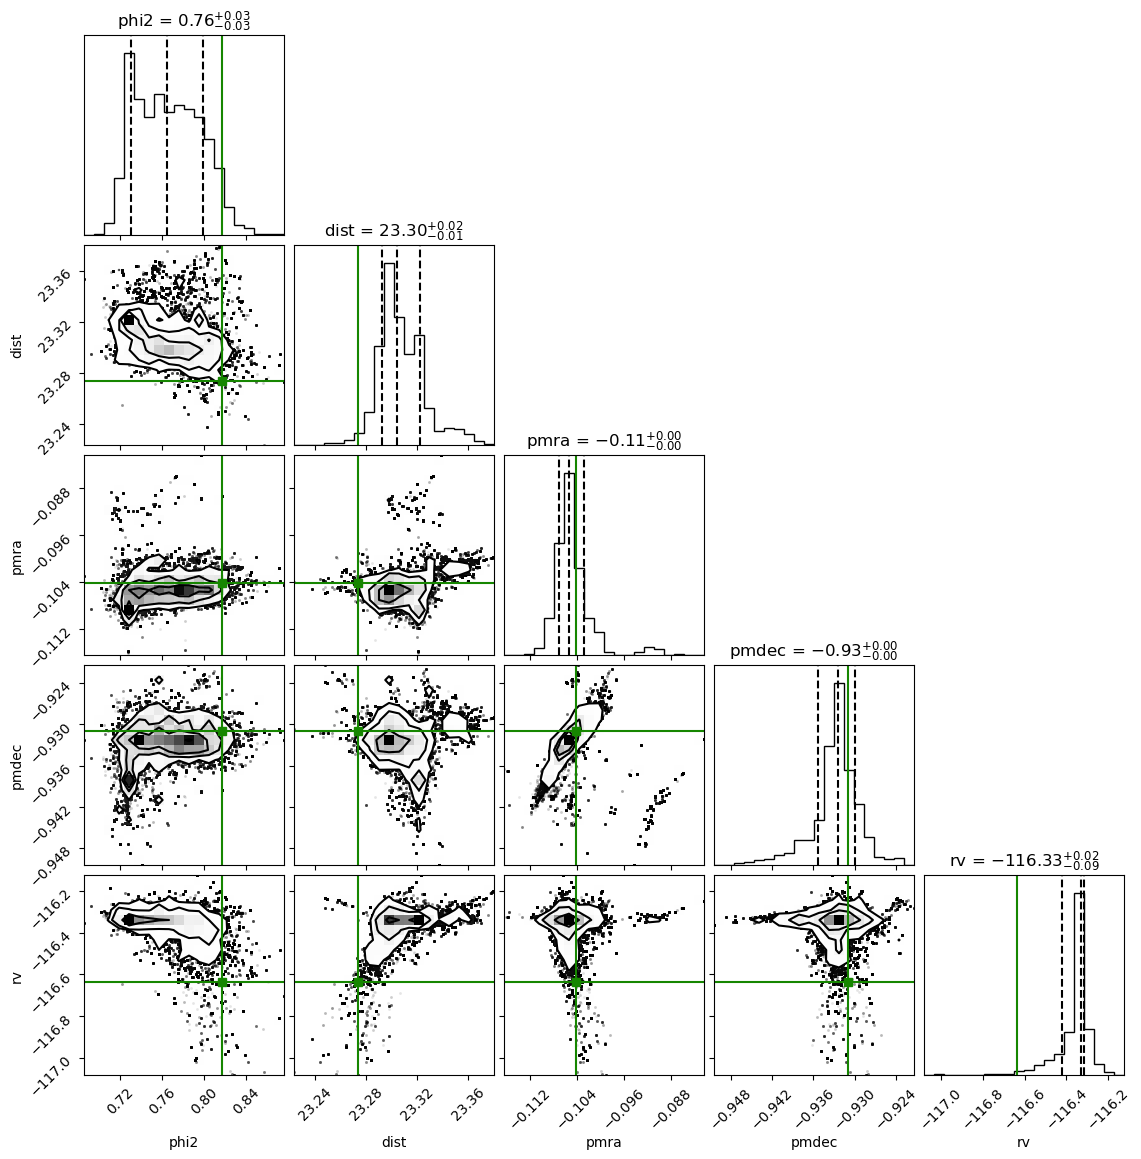

In [19]:
#MCMC checks!
labels = ['phi2', 'dist', 'pmra', 'pmdec', 'rv']

fig = corner.corner(
    samples,
    labels=labels,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 12},
    truths=prog_pars_max,  # Show best fit
    truth_color='#168600', fig_kwargs={'figsize': (4, 4)}
)
plt.show()

In [20]:
#generate the stream with best_fit_params
gen_best_stream = create_stream_particle_spray(
    pot_host=potTotal, 
    initmass=prog_mass, 
    scaleradius=prog_scaleradius, 
    prog_pot_kind='Plummer', 
    sat_cen_present=prog_gal_best, 
    num_particles=num_particles,
    time_end=0.0, 
    time_total=Age_stream_inGyr, save_rate=1,
    #add_perturber={'mass':0},
)

#Cleaning up our coordinate frames *whistles nonchalantly*
best_stream_model = gen_best_stream['part_xv']

galcen_best_stream = coord.Galactocentric(
        x=best_stream_model[:,0] * u.kpc,
        y=best_stream_model[:,1] * u.kpc,
        z=best_stream_model[:,2] * u.kpc,
        v_x=best_stream_model[:,3] * u.km/u.s,
        v_y=best_stream_model[:,4] * u.km/u.s,
        v_z=best_stream_model[:,5] * u.km/u.s,
        representation_type='cartesian',
        differential_type='cartesian'
    )

icrs_best_stream = galcen_best_stream.transform_to(coord.ICRS())

ra_max = icrs_best_stream.ra.value
dec_max = icrs_best_stream.dec.value
dist_max = icrs_best_stream.distance.value
pmra_max = icrs_best_stream.pm_ra_cosdec.value
pmdec_max = icrs_best_stream.pm_dec.value
rv_max = icrs_best_stream.radial_velocity.value

phi1_max, phi2_max = icrs_to_sf(ra_max, dec_max, aau_rot_matrix)

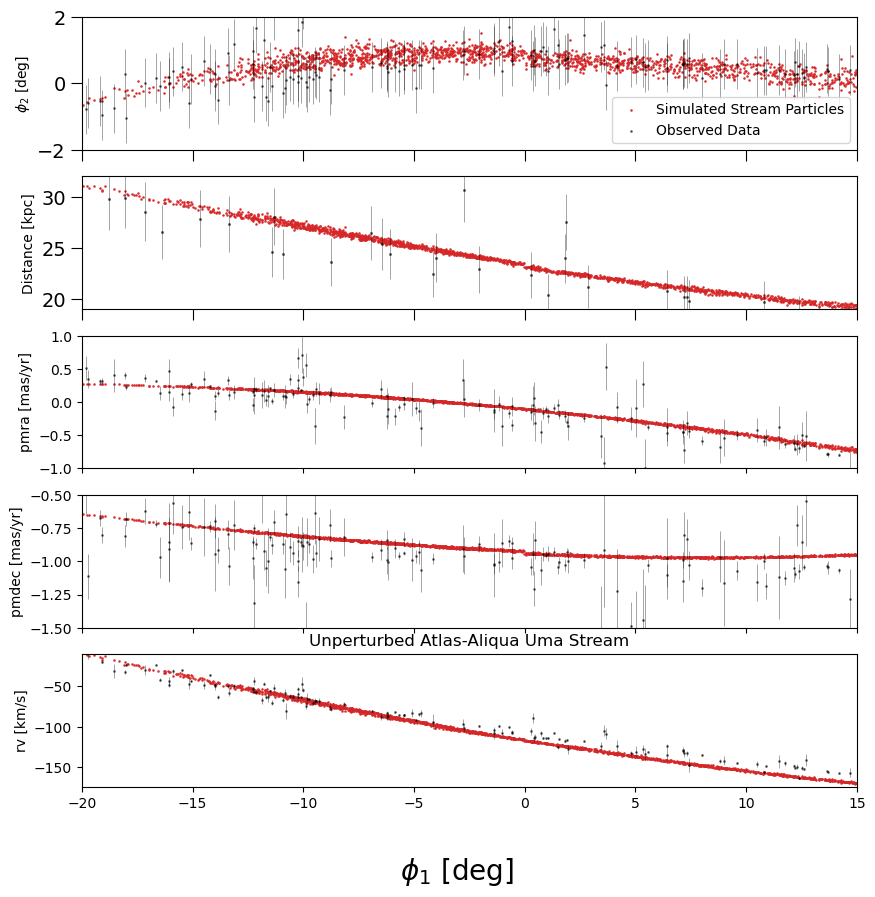

In [26]:
#plot with best-fit progenitor IC's from MCMC!

fig, ax = plt.subplots(5,1, sharex = True)
fig.set_size_inches(10,10)
fig.supxlabel(r'$\phi_1$ [deg]',fontsize=20)
ax[-1].set_xlim(-20,15)
ax[-1].set_title(label ='Unperturbed Atlas-Aliqua Uma Stream',loc='center' )
#simulation
ax[0].scatter(phi1_max, phi2_max,s=0.75,color='tab:red', alpha= 0.9, label = 'Simulated Stream Particles')
ax[0].tick_params(axis='both', which='major', labelsize=14., length=8)
ax[0].tick_params(axis='both', which='minor', length=3)
ax[0].set_ylim(-2,2)

ax[0].set_ylabel(r'$\phi_2$ [deg]', fontsize=10)
ax[1].scatter(phi1_max, dist_max,s=0.75,color='tab:red',alpha= 0.9 )
ax[1].tick_params(axis='both', which='major', labelsize=14., length=8)
ax[1].tick_params(axis='both', which='minor', length=3)
ax[1].set_ylabel('Distance [kpc]', fontsize=10)
ax[1].set_ylim(19,32)

ax[2].scatter(phi1_max, pmra_max,s=0.75,color='tab:red',alpha= 0.9 )
ax[2].set_ylim(-1,1)
ax[2].set_ylabel('pmra [mas/yr]', fontsize=10)

ax[3].scatter(phi1_max, pmdec_max,s=0.75,color='tab:red',alpha= 0.9 )
ax[3].set_ylabel('pmdec [mas/yr]', fontsize=10)
ax[3].set_ylim(-1.5,-0.5)

ax[4].scatter(phi1_max, rv_max,s=0.75,color='tab:red',alpha= 0.9)
ax[4].set_ylabel('rv [km/s]', fontsize=10)
ax[4].set_ylim(-175,-10)

#data
ax[0].scatter(df_aau['phi1'], df_aau['phi2'] , s=1,color='k', alpha = 0.5, label = 'Observed Data')
ax[0].errorbar(df_aau['phi1'], df_aau['phi2'], yerr=np.nanstd(df_aau['phi2']), fmt='none', ecolor='k', alpha = 0.5, capsize=0, capthick=0.7, elinewidth=0.5)

ax[1].scatter(df_distance_aau['phi1'],(10**((df_distance_aau['distance_modulus'])/5 +1)*1e-3),s=1.5,color='k', alpha = 0.5)
ax[1].errorbar(df_distance_aau['phi1'],(10**((df_distance_aau['distance_modulus'])/5 +1)*1e-3), yerr=np.abs(((10**((df_distance_aau['distance_modulus'])/5 +1)*1e-3))*0.1), fmt='none', ecolor='k',alpha = 0.5,capsize=0, capthick=0.7, elinewidth=0.5)


ax[2].scatter(df_aau['phi1'], df_aau['pmra'],s=1,color='k', alpha = 0.5)
ax[2].errorbar(df_aau['phi1'], df_aau['pmra'], yerr=df_aau['pmra_error'], fmt='none', ecolor='k',alpha = 0.5,capsize=0, capthick=0.7, elinewidth=0.5)

ax[3].scatter(df_aau['phi1'], df_aau['pmdec'],s=1,color='k',alpha = 0.5)
ax[3].errorbar(df_aau['phi1'], df_aau['pmdec'], yerr=df_aau['pmdec_error'], fmt='none', ecolor='k', alpha = 0.5, capsize=0, capthick=0.7, elinewidth=0.5)

ax[4].scatter(df_aau['phi1'], df_aau['vel_calib'],s=1,color='k', alpha = 0.5)
ax[4].errorbar(df_aau['phi1'], df_aau['vel_calib'], yerr=df_aau['vel_calib_std'], fmt='none', ecolor='k',alpha = 0.5, capsize=0, capthick=0.7, elinewidth=0.5)

ax[0].legend(loc = 'lower right')


In [33]:
#plotting with corner plot histogram values

prog_pars_hist = [0, 0.76, 23.30, -0.11, -0.93, -116.33]
ra_hist, dec_hist = sf_to_icrs(prog_pars_hist[0], prog_pars_hist[1], aau_rot_matrix)
dist_hist, pmra_hist, pmdec_hist, rv_hist = prog_pars_hist[2:]

aau_c_hist = coord.SkyCoord(
    ra=ra_hist*u.degree, dec=dec_hist*u.degree, distance=dist_hist*u.kpc, 
    pm_ra_cosdec=pmra_hist*u.mas/u.yr,
    pm_dec=pmdec_hist*u.mas/u.yr,
    radial_velocity=rv_hist*u.km/u.s
)

rep_hist = aau_c_hist.transform_to(coord.Galactocentric) # units here are kpc, km/s

prog_hist_gal = np.array(
    [rep_hist.x.value, rep_hist.y.value, rep_hist.z.value,
     rep_hist.v_x.value, rep_hist.v_y.value, rep_hist.v_z.value]
) # units here are kpc, km/s

#generate the stream with best_fit_params
gen_hist_stream = create_stream_particle_spray(
    pot_host=potTotal, 
    initmass=prog_mass, 
    scaleradius=prog_scaleradius, 
    prog_pot_kind='Plummer', 
    sat_cen_present=prog_hist_gal, 
    num_particles=num_particles,
    time_end=0.0, 
    time_total=Age_stream_inGyr, save_rate=1,
    #add_perturber={'mass':0},
)

#Cleaning up our coordinate frames *whistles nonchalantly*
hist_stream_model = gen_hist_stream['part_xv']

galcen_hist_stream = coord.Galactocentric(
        x=hist_stream_model[:,0] * u.kpc,
        y=hist_stream_model[:,1] * u.kpc,
        z=hist_stream_model[:,2] * u.kpc,
        v_x=hist_stream_model[:,3] * u.km/u.s,
        v_y=hist_stream_model[:,4] * u.km/u.s,
        v_z=hist_stream_model[:,5] * u.km/u.s,
        representation_type='cartesian',
        differential_type='cartesian'
    )

icrs_hist_stream = galcen_hist_stream.transform_to(coord.ICRS())

ra_h = icrs_hist_stream.ra.value
dec_h = icrs_hist_stream.dec.value
dist_h = icrs_hist_stream.distance.value
pmra_h = icrs_hist_stream.pm_ra_cosdec.value
pmdec_h = icrs_hist_stream.pm_dec.value
rv_h = icrs_hist_stream.radial_velocity.value

phi1_h, phi2_h = icrs_to_sf(ra_h, dec_h, aau_rot_matrix)

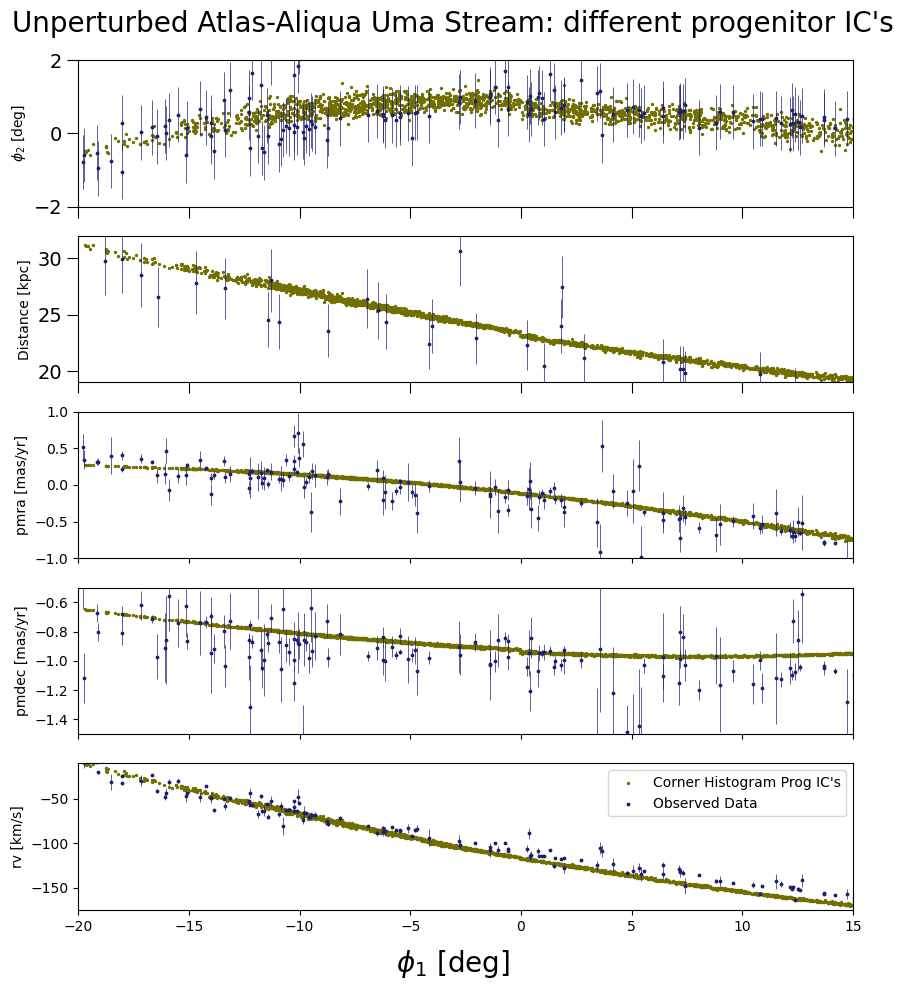

In [38]:
fig, ax = plt.subplots(5,1, sharex = True)
fig.suptitle(t ="Unperturbed Atlas-Aliqua Uma Stream: different progenitor IC's",ha= 'center', fontsize = 20 )
fig.set_size_inches(10,10)
plt.subplots_adjust(top=0.93, bottom = 0.08)
fig.supxlabel(r'$\phi_1$ [deg]',fontsize=20)
ax[-1].set_xlim(-20,15)
#simulation
ax[0].scatter(phi1_h, phi2_h,s=2,color='#716f00', label = "Corner Histogram Prog IC's")
ax[0].tick_params(axis='both', which='major', labelsize=14., length=8)
ax[0].tick_params(axis='both', which='minor', length=3)
ax[0].set_ylim(-2,2)

ax[0].set_ylabel(r'$\phi_2$ [deg]', fontsize=10)
ax[1].scatter(phi1_h, dist_h,s=2,color='#716f00' )
ax[1].tick_params(axis='both', which='major', labelsize=14., length=8)
ax[1].tick_params(axis='both', which='minor', length=3)
ax[1].set_ylabel('Distance [kpc]', fontsize=10)
ax[1].set_ylim(19,32)

ax[2].scatter(phi1_h, pmra_h,s=2,color='#716f00' )
ax[2].set_ylim(-1,1)
ax[2].set_ylabel('pmra [mas/yr]', fontsize=10)

ax[3].scatter(phi1_h, pmdec_h,s=2,color='#716f00' )
ax[3].set_ylabel('pmdec [mas/yr]', fontsize=10)
ax[3].set_ylim(-1.5,-0.5)

ax[4].scatter(phi1_h, rv_h,s=2,color='#716f00',label = "Corner Histogram Prog IC's")
ax[4].set_ylabel('rv [km/s]', fontsize=10)
ax[4].set_ylim(-175,-10)


# #theta_max IC's
# ax[0].scatter(phi1_max, phi2_max,s=2,color='#5a1149', label = "MCMC Sampler Max IC's")
# ax[0].tick_params(axis='both', which='major', labelsize=14., length=8)
# ax[0].tick_params(axis='both', which='minor', length=3)
# ax[0].set_ylim(-2,2)

# ax[0].set_ylabel(r'$\phi_2$ [deg]', fontsize=10)
# ax[1].scatter(phi1_max, dist_max,s=2,color='#5a1149' )
# ax[1].tick_params(axis='both', which='major', labelsize=14., length=8)
# ax[1].tick_params(axis='both', which='minor', length=3)
# ax[1].set_ylabel('Distance [kpc]', fontsize=10)
# ax[1].set_ylim(19,32)

# ax[2].scatter(phi1_max, pmra_max,s=2,color='#5a1149' )
# ax[2].set_ylim(-1,1)
# ax[2].set_ylabel('pmra [mas/yr]', fontsize=10)

# ax[3].scatter(phi1_max, pmdec_max,s=2,color='#5a1149' )
# ax[3].set_ylabel('pmdec [mas/yr]', fontsize=10)
# ax[3].set_ylim(-1.5,-0.5)

# ax[4].scatter(phi1_max, rv_max,s=2,color='#5a1149', label = "MCMC Sampler Max IC's")
# ax[4].set_ylabel('rv [km/s]', fontsize=10)
# ax[4].set_ylim(-175,-10)


#data
ax[0].scatter(df_aau['phi1'], df_aau['phi2'] , s=3,color='#1e1f6f', label = 'Observed Data')
ax[0].errorbar(df_aau['phi1'], df_aau['phi2'], yerr=np.nanstd(df_aau['phi2']), fmt='none', ecolor='#1e1f6f', capsize=0, capthick=0.7, elinewidth=0.5)

ax[1].scatter(df_distance_aau['phi1'],(10**((df_distance_aau['distance_modulus'])/5 +1)*1e-3),s=3,color='#1e1f6f')
ax[1].errorbar(df_distance_aau['phi1'],(10**((df_distance_aau['distance_modulus'])/5 +1)*1e-3), yerr=np.abs(((10**((df_distance_aau['distance_modulus'])/5 +1)*1e-3))*0.1), fmt='none', ecolor='#1e1f6f',capsize=0, capthick=0.7, elinewidth=0.5)


ax[2].scatter(df_aau['phi1'], df_aau['pmra'],s=3,color='#1e1f6f')
ax[2].errorbar(df_aau['phi1'], df_aau['pmra'], yerr=df_aau['pmra_error'], fmt='none', ecolor='#1e1f6f',capsize=0, capthick=0.7, elinewidth=0.5)

ax[3].scatter(df_aau['phi1'], df_aau['pmdec'],s=3,color='#1e1f6f')
ax[3].errorbar(df_aau['phi1'], df_aau['pmdec'], yerr=df_aau['pmdec_error'], fmt='none', ecolor='#1e1f6f', capsize=0, capthick=0.7, elinewidth=0.5)

ax[4].scatter(df_aau['phi1'], df_aau['vel_calib'],s=3,color='#1e1f6f', label = 'Observed Data')
ax[4].errorbar(df_aau['phi1'], df_aau['vel_calib'], yerr=df_aau['vel_calib_std'], fmt='none', ecolor='#1e1f6f', capsize=0, capthick=0.7, elinewidth=0.5)

ax[4].legend(loc = 'upper right')
